In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Set premium aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [6]:
# Load the salary dataset
df = pd.read_csv('car_data.csv')
print("📊 Dataset Preview:")
print(df.head())

# Independent variables (X)
X = df[['weight','volume']]

# Dependent variable (y)
y = df['CO2']

📊 Dataset Preview:
  car_model  volume  weight  CO2
0    Toyota    1100     800  101
1     Honda    1400     950  112
2      Ford    1800    1300  120
3       BMW    2000    1450  130
4      Audi    2200    1500  135


In [7]:
# Initialize and Train the Multiple Regression Model
model = LinearRegression()
model.fit(X, y)

print("✅ Multiple Regression model trained successfully.")

# Output the coefficients and intercept
print(f"\nCoefficients (Weight, Volume): {model.coef_}")
print(f"Intercept: {model.intercept_:.4f}")

✅ Multiple Regression model trained successfully.

Coefficients (Weight, Volume): [0.0466464  0.00126412]
Intercept: 61.5747


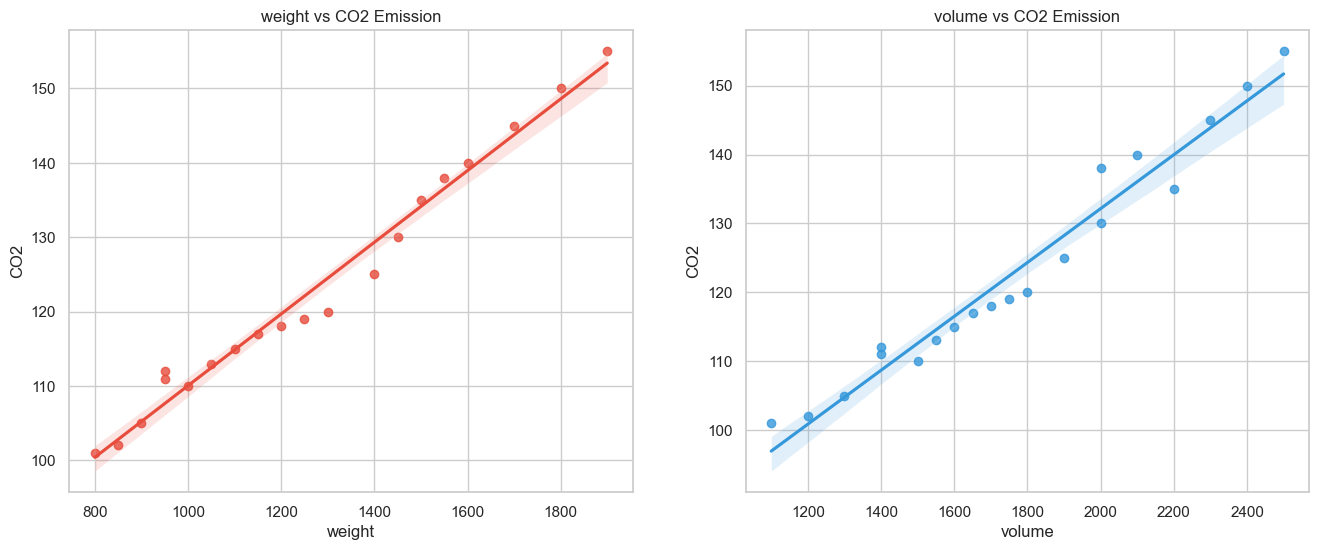

In [9]:
# Visualize relationships
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.regplot(x='weight', y='CO2', data=df, ax=ax1, color='#e74c3c')
ax1.set_title('weight vs CO2 Emission')

sns.regplot(x='volume', y='CO2', data=df, ax=ax2, color='#3498db')
ax2.set_title('volume vs CO2 Emission')

plt.show()

In [10]:
# Custom Prediction Function with User Input
def predict_co2(weight, volume):
    prediction = model.predict([[weight, volume]])[0]
    print(f"\n🔮 Predicted CO2 Emission:")
    print(f"weight: {weight}kg, volume: {volume}ccm")
    print(f"Estimated CO2: {prediction:.2f}g/km")

# Get input from the user
try:
    u_weight = float(input("Enter car weight (kg): "))
    u_volume = float(input("Enter engine volume (ccm): "))
    predict_co2(u_weight, u_volume)
except ValueError:
    print("❌ Please enter numeric values.")


🔮 Predicted CO2 Emission:
Weight: 56.0kg, Volume: 1000.0ccm
Estimated CO2: 65.45g/km


c:\Users\GOPIKA RAVEENDRAN\Desktop\Gopz\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [11]:
# Model Evaluation
y_pred = model.predict(X)
accuracy = r2_score(y, y_pred)
print(f"\n📈 Model R² Score: {accuracy:.4f}")
print("(Note: R² indicates how well the independent variables explain the variance of CO2)")


📈 Model R² Score: 0.9803
(Note: R² indicates how well the independent variables explain the variance of CO2)
